**FORMULA 1 ANALYSIS**


**Data Description**

The datasets used in this project include:

Circuits: Information about the racing circuits.
Constructor Results: Results of each constructor in the races.
Constructor Standings: Standings of constructors in the championship.
Constructors: Information about constructors.
Driver Standings: Standings of drivers in the championship.
Drivers: Information about drivers.
Lap Times: Lap times for each driver in each race.
Pit Stops: Data on pit stops during races.
Qualifying: Qualifying results for drivers.
Races: Details of each race.
Results: Results of each race.
Seasons: Information about the seasons.
Sprint Results: Results from sprint races.
Status: Status of drivers in each race.


In [1]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [2]:
# Load the datasets
circuits = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/circuits.csv')
constructor_results = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/constructor_results.csv')
constructor_standings = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/constructor_standings.csv')
constructors = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/constructors.csv')
driver_standings = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/driver_standings.csv')
drivers = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/drivers.csv')
lap_times = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/lap_times.csv')
pit_stops = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/pit_stops.csv')
qualifying = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/qualifying.csv')
races = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/races.csv')
results = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/results.csv')
seasons = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/seasons.csv')
sprint_results = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/sprint_results.csv')
status = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/status.csv')

**RACE WINS BY DRIVER**

Find out which top 5 drivers have won the most races.

In [12]:
# Filter to get race winners
winners = results[results['positionOrder'] == 1]

# Count wins for each driver
wins_each = winners.groupby('driverId').size().reset_index(name='wins')

# Merge with driver names
wins_names = pd.merge(wins_each, drivers[['driverId', 'surname']], on='driverId')
print(wins_names.sort_values(by='wins', ascending=False).head())

     driverId  wins     surname
0           1   104    Hamilton
15         30    91  Schumacher
107       830    61  Verstappen
11         20    53      Vettel
29        117    51       Prost


<Figure size 1000x600 with 0 Axes>

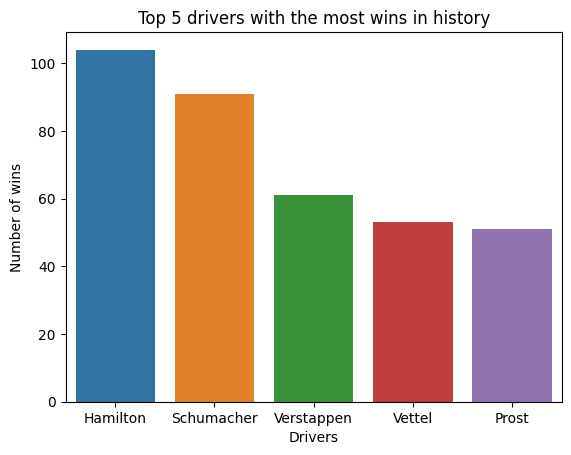

<Figure size 1000x600 with 0 Axes>

In [20]:
top_5 = wins_names.sort_values(by='wins', ascending=False).head()
names = top_5['surname'].head()
top_5_wins = top_5['wins'].head()

# Bar chart showing top 5 drivers with the most wins
sns.barplot(x=names, y=top_5_wins)

# labels
plt.title('Top 5 drivers with the most wins in history')
plt.xlabel("Drivers")
plt.ylabel("Number of wins")
plt.figure(figsize=(10,6))

**DRIVER WINS OVER TIME**

Visualize the number of wins for the Lewis Hamilton

    year   surname  wins  cumulative_wins
0   2007  Hamilton     4                4
1   2008  Hamilton     5                9
2   2009  Hamilton     2               11
3   2010  Hamilton     3               14
4   2011  Hamilton     3               17
5   2012  Hamilton     4               21
6   2013  Hamilton     1               22
7   2014  Hamilton    11               33
8   2015  Hamilton    10               43
9   2016  Hamilton    10               53
10  2017  Hamilton     9               62
11  2018  Hamilton    11               73
12  2019  Hamilton    11               84
13  2020  Hamilton    11               95
14  2021  Hamilton     8              103
15  2024  Hamilton     1              104


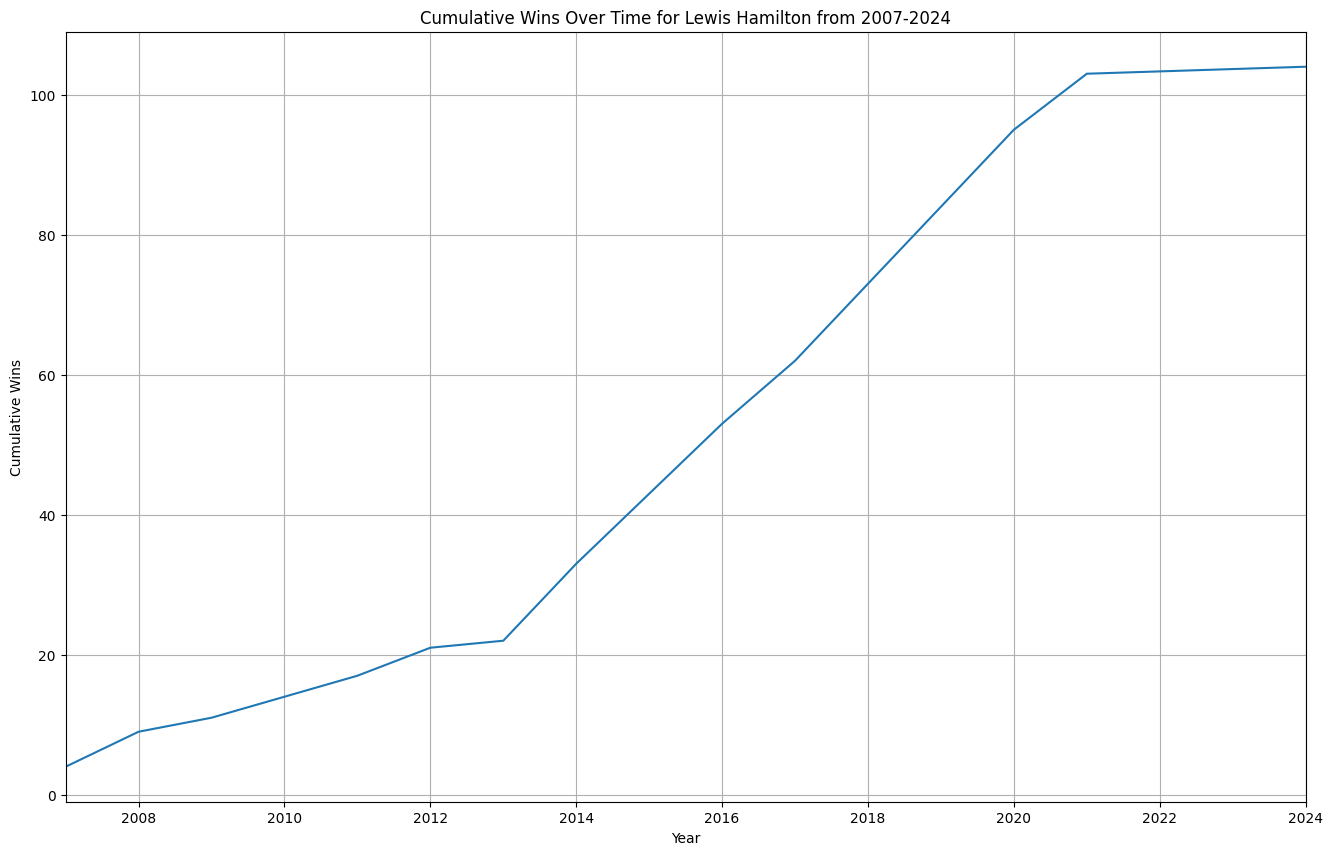

In [97]:
# Merge winners with race data to get the year
winners_year = winners.merge(races[['raceId', 'year']], on='raceId')

# Merge with driver data to get driver names
winner_names = winners_year.merge(drivers[['driverId', 'surname']], on='driverId')

# Filter for Lewis Hamilton
lh = winner_names[winner_names['surname']=='Hamilton']

# Group by year and driver to count wins per year
wins_per_year = lh.groupby(['year', 'surname']).size().reset_index(name='wins')

# Create a cumulative sum of wins over time for each driver
wins_per_year['cumulative_wins'] = wins_per_year.groupby('surname')['wins'].cumsum()
print(wins_per_year)

# Plot the data as a line chart
plt.figure(figsize=(16, 10))

plt.plot(wins_per_year['year'], wins_per_year['cumulative_wins'])

plt.title('Cumulative Wins Over Time for Lewis Hamilton from 2007-2024')
plt.xlabel('Year')
plt.ylabel('Cumulative Wins')
plt.xlim(2007, 2024)
plt.grid(True)

**RACE WINS BY NATIONALITY**

Pie chart to show the percentages of 1st place podiums by drivers' nationalities.

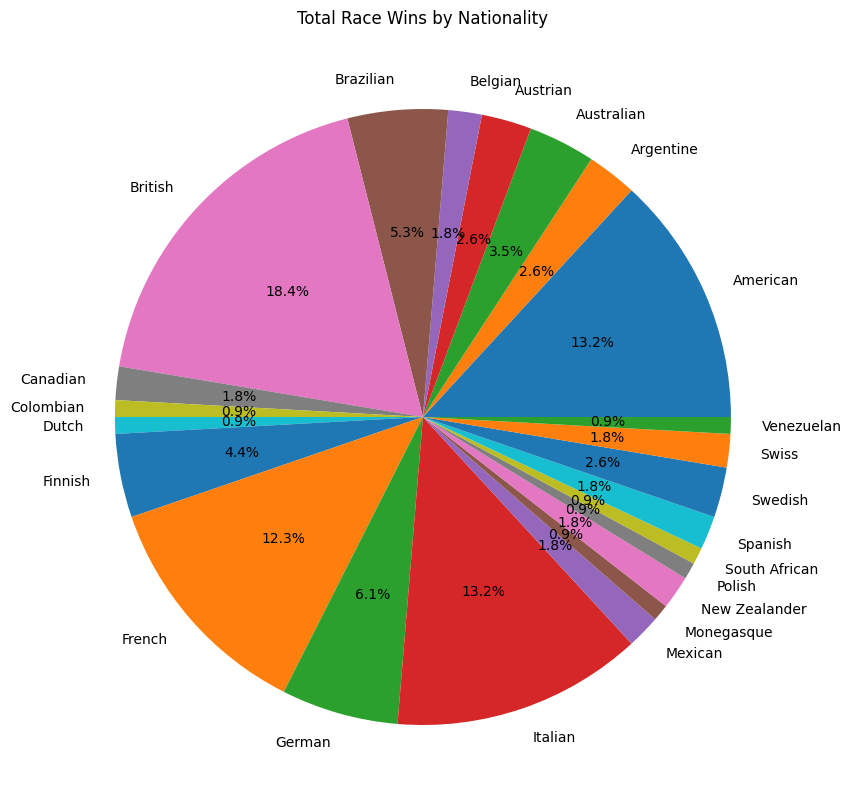

In [91]:
# Filter to get race winners
winners = results[results['positionOrder'] == 1]

# Count wins for each driver
wins_each = winners.groupby('driverId').size().reset_index(name='wins')

# Merge with driver name and nationality
wins_names = pd.merge(wins_each, drivers[['driverId', 'nationality']], on='driverId')

# Count wins for each nationality
wins_nat = wins_names.groupby('nationality').size().reset_index(name='total wins')
wins_nat.sort_values(by='total wins', ascending=False).head()

# Plot pie chart of wins by nationality
plt.figure(figsize=(10, 10))
plt.pie(wins_nat['total wins'], labels=wins_nat['nationality'], autopct = '%1.1f%%')
plt.title('Total Race Wins by Nationality')
plt.show()

**Constructor Championship Performance**

Analyze which constructor has the most podiums (1st-3rd place) over time.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75]),
 [Text(0, 0, 'McLaren'),
  Text(1, 0, 'BMW Sauber'),
  Text(2, 0, 'Williams'),
  Text(3, 0, 'Renault'),
  Text(4, 0, 'Toro Rosso'),
  Text(5, 0, 'Ferrari'),
  Text(6, 0, 'Toyota'),
  Text(7, 0, 'Red Bull'),
  Text(8, 0, 'Force India'),
  Text(9, 0, 'Honda'),
  Text(10, 0, 'Sauber'),
  Text(11, 0, 'BAR'),
  Text(12, 0, 'Jordan'),
  Text(13, 0, 'Jaguar'),
  Text(14, 0, 'Prost'),
  Text(15, 0, 'Arrows'),
  Text(16, 0, 'Benetton'),
  Text(17, 0, 'Brawn'),
  Text(18, 0, 'Stewart'),
  Text(19, 0, 'Tyrrell'),
  Text(20, 0, 'Lola'),
  Text(21, 0, 'Ligier'),
  Text(22, 0, 'Footwork'),
  Text(23, 0, 'Team Lotus'),
  Text(24, 0, 'Larrousse'),
  Text(25, 0, 

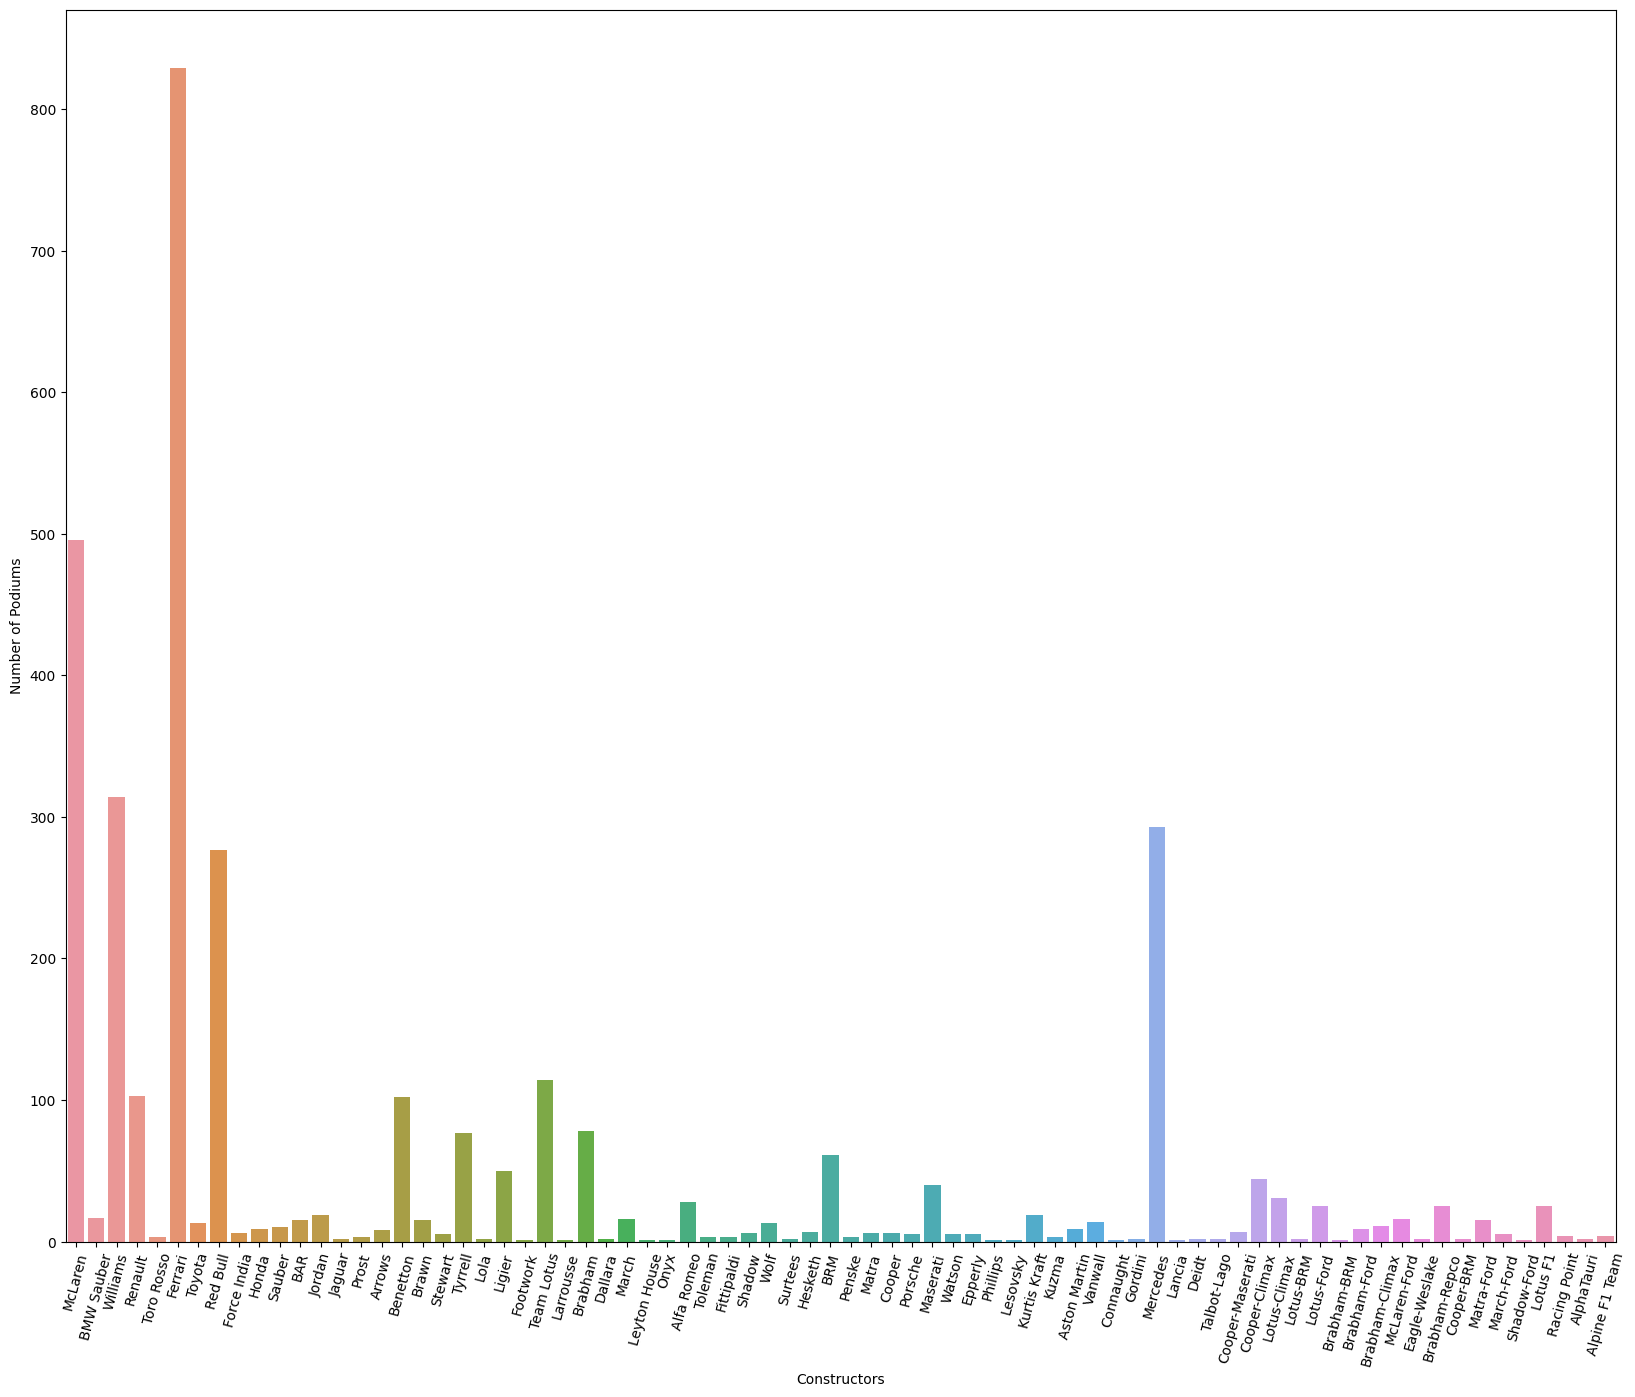

In [28]:
# get all of the podium results
podiums = results[results['positionOrder'].isin([1,2,3])]

# count the podium finishes by constructorId
constructor_finish = podiums.groupby('constructorId').size().reset_index(name='podiums')

# get constructors names based off their id
constructor_name = pd.merge(constructor_finish, constructors[['constructorId', 'name']], on='constructorId')

# bar chart
plt.figure(figsize=(20, 16))
sns.barplot(x=constructor_name['name'], y = constructor_name['podiums'])
plt.xlabel('Constructors')
plt.ylabel("Number of Podiums")
plt.xticks(rotation=75)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

Text(0.5, 1.0, '2019 Rookies Performance Over Time')

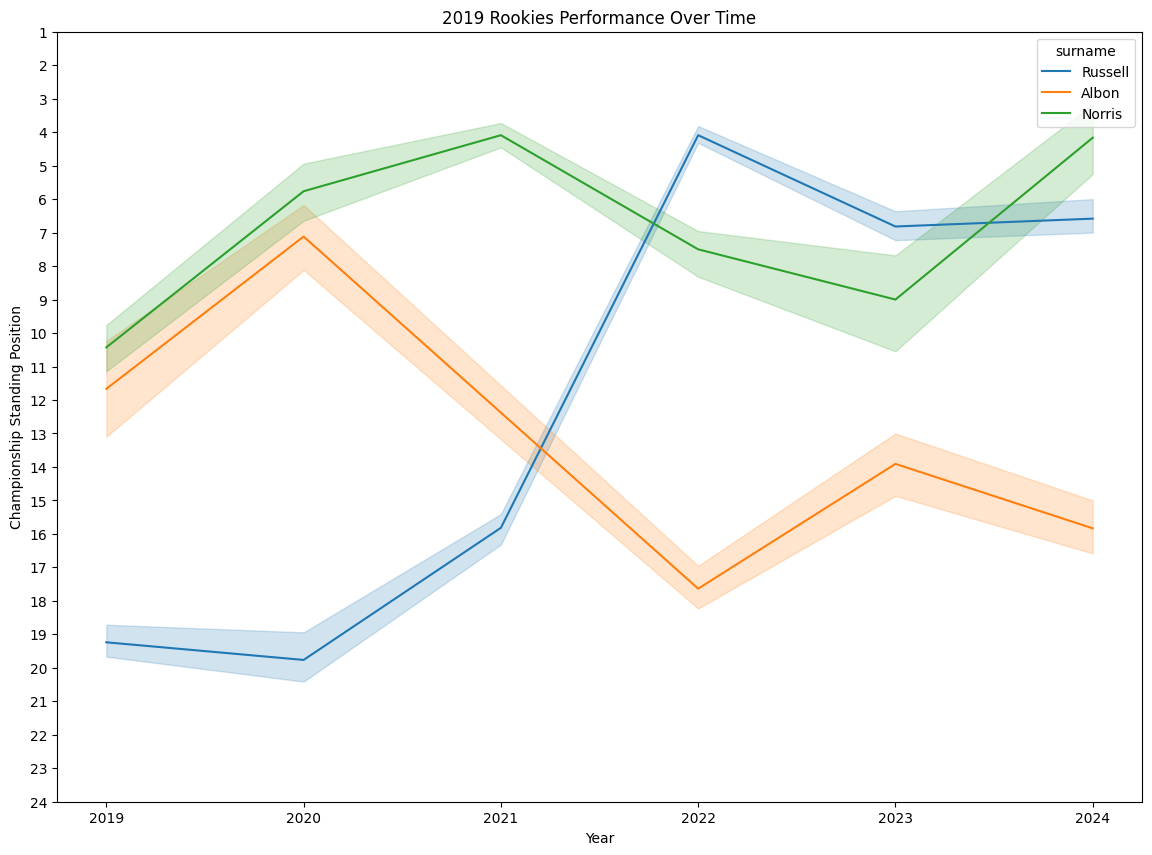

In [74]:
# merge data to get driver standing by year
standing = pd.merge(driver_standings, drivers[['driverId', 'surname']], on = 'driverId')
standing = pd.merge(standing, races[['raceId', 'year']], on = 'raceId')
#print(standing.head())

# filter for 2019 rookies
names = ['Norris','Albon', 'Russell']
performance = standing[standing['surname'].isin(names)]
performance = performance[performance['year'] >= 2019]

# graph data
plt.figure(figsize=(14,10))
sns.lineplot(data=performance, x=performance['year'], y=performance['position'], hue='surname')
plt.gca().invert_yaxis()
plt.yticks(range(1,25))
plt.xlabel('Year')
plt.ylabel('Championship Standing Position')
plt.title("2019 Rookies Performance Over Time")

**Pole Position and Race Outcome Correlation**

Analyze how often drivers who qualify for pole position end up winning the race. Calculate the probability of winning based on starting from pole position.

In [14]:
# filter out pole positions from results
pole = results[results['grid'] == 1]

# filter out to determine where drivers on pole position won the race
wins = pole[pole['positionOrder'] == 1]
#print(wins.head())

# calculate the probability of winning from pole position
prob = len(wins) / len(pole)

# Step 4: Print the result
print(f"Probability of winning race from pole position: {prob:.2%}")

Probability of winning race from pole position: 42.35%


**Predicting Podium Finishes**


Confusion Matrix:
[[4511  155]
 [ 506  132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      4666
           1       0.46      0.21      0.29       638

    accuracy                           0.88      5304
   macro avg       0.68      0.59      0.61      5304
weighted avg       0.85      0.88      0.85      5304



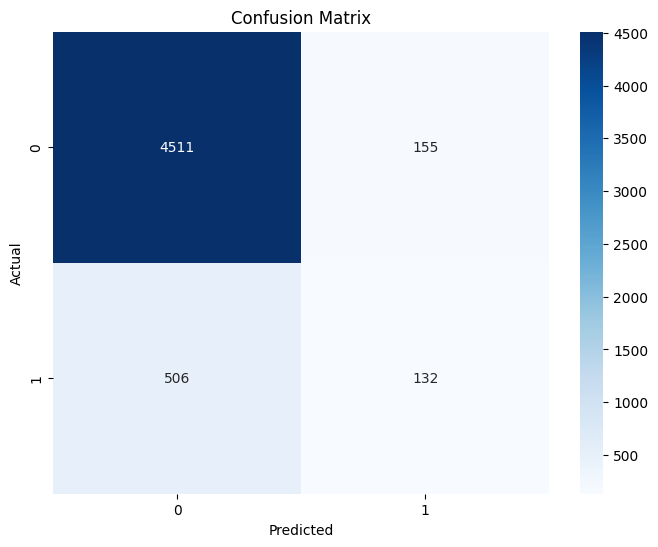

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Merge results with drivers to get driver names
data = pd.merge(results, drivers[['driverId', 'surname']], on='driverId')

# Create a binary column for podium finishes (1 if positionOrder is 1, 2, or 3, else 0)
data['podium'] = np.where(data['positionOrder'].isin([1, 2, 3]), 1, 0)

# Select relevant features for the model
features = data[['grid', 'raceId', 'driverId']]
target = data['podium']

# Encode categorical variables (e.g., driverId and raceId) if necessary
features = pd.get_dummies(features, columns=['driverId', 'raceId'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Create and fit the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
